In [ ]:
!pip install Counter

  Preparing metadata (setup.py) ... done
  Created wheel for Counter: filename=Counter-1.0.0-py3-none-any.whl size=5392 sha256=cd2a7be2d82d90944b444ddddc6038287197d83ea37ebe41fd992be72666dd94
  Stored in directory: /root/.cache/pip/wheels/16/ff/7a/6e8bf2fdadb47c50a03bb4b9a59bd2b1da1b876faf8e3815d9
Successfully built Counter


In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
def load_text(filepath):
  with open(filepath, 'r') as f:
    text = f.read()
  return text

In [ ]:
from nltk.sem.drt import Tokens
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
def clean_text(text):
  text = text.lower()
  text = re.sub(r'http\s+|www\S+|https\S+','',text,flags=re.MULTILINE)
  text = re.sub(r'\@\w+|\#','',text)
  text = text.translate(str.maketrans('','',string.punctuation))
  text = re.sub(r'\d+','',text)
  text = text.strip()

  stop_words = set(stopwords.words('english'))
  lemmatizer = WordNetLemmatizer()

  Tokens = text.split()
  token = [lemmatizer.lemmatize(word) for word in Tokens if not word in stop_words]
  text = ' '.join(token)

  return text

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
def calculate_word_frequency(text):
  words = re.findall(r'\b\w+\b', text.lower())
  word_freq = Counter(words)
  return word_freq

In [ ]:
def plot_word_frequency(word_freq, top_n = 10):
  top_words = word_freq.most_common(top_n)
  words, frequencies = zip(*top_words)
  plt.plot(words, frequencies, marker = 'o')
  plt.xlabel('Words')
  plt.ylabel('Frequencies')
  plt.title(f'Top {top_n} Words Frequencies')
  plt.xticks(rotation = 45)
  plt.show()

text: US woman sues over ink cartridges

A US woman is suing Hewlett Packard (HP), saying its printer ink cartridges are secretly programmed to expire on a certain date.

The unnamed woman from Georgia says that a chip inside the cartridge tells the printer that it needs re-filling even when it does not. The lawsuit seeks to represent anyone in the US who has purchased an HP inkjet printer since February 2001. HP, the world's biggest printer firm, declined to comment on the lawsuit. HP ink cartridges use a chip technology to sense when they are low on ink and advise the user to make a change.

But the suit claims the chips also shut down the cartridges at a predetermined date regardless of whether they are empty. "The smart chip is dually engineered to prematurely register ink depletion and to render a cartridge unusable through the use of a built-in expiration date that is not revealed to the consumer," the suit said. The lawsuit is asking for restitution, damages and other compensati

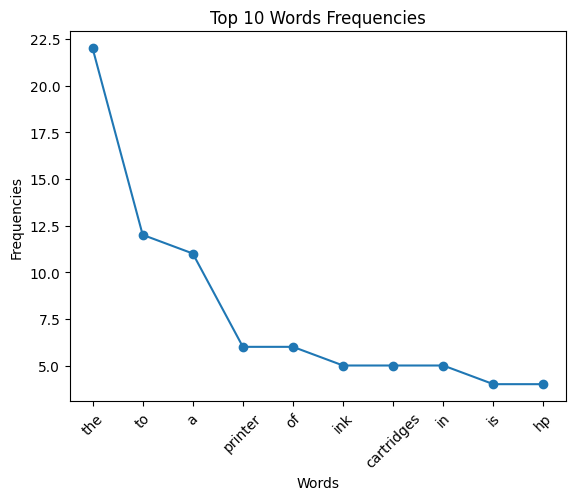

In [ ]:
if __name__ == '__main__':
  text = load_text('/content/333.txt')
  print('text:',text)
  clean = clean_text(text)
  print('Cleaned text:', clean)
  word_freq = calculate_word_frequency(text)
  plot_word_frequency(word_freq)